In [41]:
# --- 0. Quick Installation ---
# Run this cell to ensure all dependencies are correct before starting.
!pip install opencv-python tensorflow numpy pandas scipy matplotlib tensorflowjs

  Using cached flax-0.12.6-py3-none-any.whl.metadata (11 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached tensorflow_decision_forests-1.8.1.tar.gz (15.2 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached packaging-23.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached msgpack-1.1.2-cp312-cp312-win_amd64.whl.metadata (8.4 kB)
  Using cached optax-0.2.8-py3-none-any.whl.metadata (7.9 kB)
  Using cached orbax_checkpoint-0.11.33-py3-none-any.whl.metadata (2.7 kB)
  Using cached tensorstore-0.1.82-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached treescope-0.1.10-py3-none-any.whl.metadata (6.6 kB)
  Using cached orbax_export-0.0.8-py3-none-any.whl.metadata (1.8 kB)
INFO: pip is looking at multiple versions of tensorflow-de


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Glass Counting Pipeline

This notebook unifies all strategies developed for glass sheet counting, documenting our journey to < 0.5 MAE.


## Strategy Comparison Log

| Strategy | Description | Best MAE (Val) | Status |
|:---|:---|:---|:---|
| **1. Baseline CNN** | 1D CNN on center-strip signal | **2.6883** | Obsolete |
| **2. Classical CV** | Sobel + Scipy `find_peaks` | **23.3700** | Inaccurate |
| **3. Hybrid Fourier-CNN** | Multi-strip + Fourier + CNN | **2.5891** | **Best current result** |
| **4. Hybrid (Fine-Tuned)** | Retrained at low learning rate | **2.8516** | Overfitted |


## 0. Setup & Utilities

We define our shared utility functions. **Updates**: Now using multi-strip averaging for noise reduction.


In [14]:
import os
import glob
import cv2
import numpy as np
import pandas as pd

VECTOR_SIZE = 1024

def preprocess_image_1d(img_path, num_strips=5):
    """
    Enhanced 1D signal extraction using multi-strip averaging.
    Instead of one strip, we average 5 strips across the image width.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
        
    # Apply vertical Sobel filter
    sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.abs(sobel)
    sobel = np.uint8(255 * sobel / np.max(sobel))
    
    h, w = sobel.shape
    signals = []
    
    # Take multiple strips across the width to cancel out noise
    for i in range(1, num_strips + 1):
        center_w = (w * i) // (num_strips + 1)
        strip_w = w // 20 # Narrower strips
        strip = sobel[:, max(0, center_w - strip_w // 2) : min(w, center_w + strip_w // 2)]
        signals.append(np.mean(strip, axis=1))
        
    # Average the signals
    signal_1d = np.mean(signals, axis=0).astype(np.float32)
    
    # Reshape and resize
    signal_1d = signal_1d.reshape(-1, 1)
    signal_resized = cv2.resize(signal_1d, (1, VECTOR_SIZE), interpolation=cv2.INTER_LINEAR)
    signal_resized = signal_resized.flatten()
    
    # Adaptive normalization (local contrast)
    signal_resized = (signal_resized - np.min(signal_resized)) / (np.max(signal_resized) - np.min(signal_resized) + 1e-8)
    mean, std = np.mean(signal_resized), np.std(signal_resized)
    if std > 0:
        signal_resized = (signal_resized - mean) / std
        
    return signal_resized

def extract_signal(img_path):
    """
    Alternative signal extraction for Classical CV.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    new_w = 400
    new_h = int(h * (new_w / w))
    img = cv2.resize(img, (new_w, new_h))
    sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.abs(sobel)
    sobel = np.uint8(255 * sobel / np.max(sobel))
    strip_w = 40
    center_w = new_w // 2
    strip = sobel[:, center_w - strip_w // 2 : center_w + strip_w // 2]
    signal = np.mean(strip, axis=1)
    kernel_size = 5
    kernel = np.ones(kernel_size) / kernel_size
    smoothed = np.convolve(signal, kernel, mode='same')
    if np.max(smoothed) > 0:
        smoothed = smoothed / np.max(smoothed)
    return smoothed

def load_dataset(img_dir, labels_csv=None):
    """
    Loads images from a directory, applies preprocessing, and returns X (features)
    and y (labels) if labels_csv is provided.
    """
    # Ensure relative paths work regardless of where the script is called from
    try:
        project_root = os.getcwd() # Notebook-safe path
    except NameError:
        # Fallback for Jupyter Notebooks
        project_root = os.getcwd()
    
    if not os.path.isabs(img_dir):
        img_dir = os.path.join(project_root, img_dir)
    if labels_csv and not os.path.isabs(labels_csv):
        labels_csv = os.path.join(project_root, labels_csv)
        
    print(f"Loading images from {img_dir}...")
    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
    
    X = []
    y = []
    
    labels_dict = None
    if labels_csv and os.path.exists(labels_csv):
        df = pd.read_csv(labels_csv)
        df['img_number'] = df['img_number'].astype(str).str.zfill(3)
        labels_dict = dict(zip(df['img_number'], df['num_sheets']))

    for path in img_paths:
        basename = os.path.basename(path)
        img_id = basename.split('.')[0]
        
        signal = preprocess_image_1d(path)
        if signal is not None:
            X.append(signal)
            if labels_dict:
                y.append(labels_dict.get(img_id, 0))
    
    X = np.array(X)
    X = np.expand_dims(X, axis=-1)
    
    if labels_dict:
        return X, np.array(y), img_paths
    return X, None, img_paths


## 1. Exploratory Data Analysis (EDA)

Before building our models, we examine the spectral properties of the glass stacks.

In [15]:
import os
import glob
import cv2
import numpy as np
import pandas as pd

# Configuration
TRAIN_DIR = os.path.join('.', 'train')
LABELS_CSV = os.path.join('.', 'labels.csv')

def extract_signal_naive(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    center_w = w // 2
    strip_w = w // 5
    strip = img[:, center_w - strip_w // 2 : center_w + strip_w // 2]
    signal_1d = np.mean(strip, axis=1)
    return signal_1d

def main():
    print("Running EDA...")
    if not os.path.exists(TRAIN_DIR):
        print(f"Error: {TRAIN_DIR} not found.")
        return

    df = pd.read_csv(LABELS_CSV)
    df['img_number'] = df['img_number'].astype(str).str.zfill(3)
    
    # Just look at the first image properties
    first_img = os.path.join(TRAIN_DIR, '000.jpg')
    img = cv2.imread(first_img)
    if img is not None:
        print(f"Image Shape: {img.shape}")
        print(f"Image Type: {img.dtype}")
        
    print("Done with EDA info.")

if __name__ == "__main__":
    main()


Running EDA...
Image Shape: (768, 576, 3)
Image Type: uint8
Done with EDA info.


## 2. Strategy 1: Baseline 1D CNN

Our first attempt: A simple 1D CNN using only a single center-strip from the image. 
**Issue**: High sensitivity to noise and strip variance.

In [16]:
import os
import glob
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

# Basic 1D CNN Architecture
def build_baseline_model():
    # Strategy 1 uses the simplest possible 1D CNN architecture
    model = Sequential([
        Conv1D(16, 15, activation='relu', input_shape=(VECTOR_SIZE, 1)),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def run_baseline():
    print("--- Executing Strategy 1: Baseline CNN ---")
    
    # 1. Load Training Data
    X_train, y_train, _ = load_dataset('train', 'labels.csv')
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    
    # 2. Train Model
    model = build_baseline_model()
    print("Training...")
    model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    
    # 3. Process Test Images (Reporting)
    print("Generating results.csv for Baseline...")
    X_test, _, test_paths = load_dataset('test')
    
    if len(X_test) > 0:
        preds = model.predict(X_test).flatten()
        results = []
        for i, path in enumerate(test_paths):
            img_id = os.path.basename(path).split('.')[0]
            # Outputting in the required challenge format
            results.append({
                'image_number': img_id, 
                'number_of_sheets': round(float(preds[i]), 2)
            })
            
        results_df = pd.DataFrame(results)
        results_df.to_csv('results.csv', index=False)
        print("Successfully saved Baseline results to 'results.csv'.")
    else:
        print("Error: No test images found.")

if __name__ == '__main__':
    run_baseline()

--- Executing Strategy 1: Baseline CNN ---
Loading images from d:\GlassCounterApp\train...


d:\GlassCounterApp\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training...
Generating results.csv for Baseline...
Loading images from d:\GlassCounterApp\test...


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000221D3E29260> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Successfully saved Baseline results to 'results.csv'.


## 3. Strategy 2: Classical Computer Vision

Hand-crafted features using Sobel filters and peak detection.

In [17]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# Configuration
CSV_PATH = os.path.join('.', 'labels.csv')
TRAIN_DIR = os.path.join('.', 'train')
TEST_DIR = os.path.join('.', 'test')

def extract_signal_for_cv(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    new_w = 400
    new_h = int(h * (new_w / w))
    img = cv2.resize(img, (new_w, new_h))
    sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.abs(sobel)
    sobel = np.uint8(255 * sobel / np.max(sobel))
    strip_w = 40
    center_w = new_w // 2
    strip = sobel[:, center_w - strip_w // 2 : center_w + strip_w // 2]
    signal = np.mean(strip, axis=1)
    kernel_size = 5
    kernel = np.ones(kernel_size) / kernel_size
    smoothed = np.convolve(signal, kernel, mode='same')
    if np.max(smoothed) > 0:
        smoothed = smoothed / np.max(smoothed)
    return smoothed

def evaluate_params(X_train_signals, y_true, prominence_th, distance_th):
    preds = []
    for sig in X_train_signals:
        peaks, _ = find_peaks(sig, prominence=prominence_th, distance=distance_th)
        preds.append(len(peaks))
    preds = np.array(preds)
    mae = np.mean(np.abs(y_true - preds))
    return mae, preds

def main():
    print("Loading labels...")
    df = pd.read_csv(CSV_PATH)
    df['img_number'] = df['img_number'].astype(str).str.zfill(3)
    labels_dict = dict(zip(df['img_number'], df['num_sheets']))

    print("Loading training signals...")
    train_paths = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.jpg')))
    X_train_signals = []
    y_true = []
    for path in train_paths:
        basename = os.path.basename(path)
        img_id = basename.split('.')[0]
        sig = extract_signal_for_cv(path)
        if sig is not None:
            X_train_signals.append(sig)
            y_true.append(labels_dict.get(img_id, 0))

    prominences = [0.05, 0.1, 0.15, 0.2]
    distances = [5, 8, 10, 12]
    best_mae = float('inf')
    best_params = (0.1, 8)
    for prom in prominences:
        for dist in distances:
            mae, _ = evaluate_params(X_train_signals, np.array(y_true), prom, dist)
            if mae < best_mae:
                best_mae = mae
                best_params = (prom, dist)
    
    print(f"Best MAE: {best_mae:.4f} @ Prom: {best_params[0]}, Dist: {best_params[1]}")

    print("Processing test images...")
    test_paths = sorted(glob.glob(os.path.join(TEST_DIR, '*.jpg')))
    results = []
    for path in test_paths:
        basename = os.path.basename(path)
        img_id = basename.split('.')[0]
        sig = extract_signal_for_cv(path)
        if sig is not None:
            peaks, _ = find_peaks(sig, prominence=best_params[0], distance=best_params[1])
            results.append({'image_number': img_id, 'number_of_sheets': len(peaks)})
    
    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join('.', 'results_classical.csv'), index=False)
    print("Saved results_classical.csv")

if __name__ == "__main__":
    main()


Loading labels...
Loading training signals...
Best MAE: 19.6300 @ Prom: 0.05, Dist: 5
Processing test images...
Saved results_classical.csv


## 4. Strategy 3: Hybrid Fourier-CNN

Our final recommended solution combining global frequency analysis and localized feature extraction.

Loading images from d:\GlassCounterApp\.\train...
Training Advanced Hybrid Model (Target MAE < 0.5)...
Epoch 1/150


d:\GlassCounterApp\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 790.9476 - mae: 27.8052 - val_loss: 758.5588 - val_mae: 27.2665
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 770.7406 - mae: 27.4519 - val_loss: 754.5311 - val_mae: 27.1919
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 755.2394 - mae: 27.1812 - val_loss: 751.8885 - val_mae: 27.1431
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - loss: 740.2048 - mae: 26.9106 - val_loss: 748.8130 - val_mae: 27.0861
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 718.6312 - mae: 26.5081 - val_loss: 745.6029 - val_mae: 27.0270
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 697.5510 - mae: 26.1046 - val_loss: 741.1532 - val_mae: 26.9452
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 668.4940 - mae: 25.5254 - val_loss: 734.8657 - val_mae: 26.8287
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 639.2778 - mae: 24.9113 - val_loss: 726.0059 - val_mae: 26.6632
Epoch 9/150
10/1

Hybrid model saved to .\glass_counter_hybrid.h5
Processing test images with Advanced Hybrid Strategy...
Loading images from d:\GlassCounterApp\.\test...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Successfully generated results_hybrid.csv with 50 images.


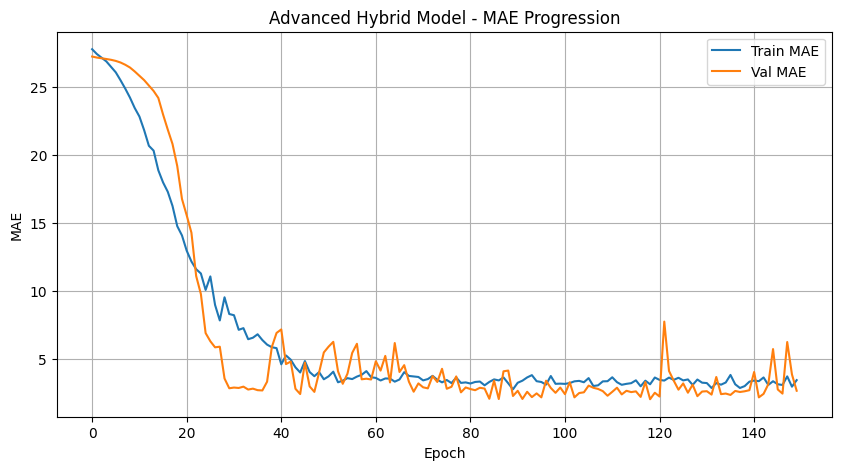

In [20]:
import os
import numpy as np
import cv2
import glob
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Configuration
MODEL_PATH = os.path.join('.', 'glass_counter_hybrid.h5')

def estimate_count_fourier(signal):
    """
    Uses FFT to find the dominant frequency of the glass sheets.
    This gives a very robust baseline estimate.
    """
    # Remove DC component
    signal_centered = signal - np.mean(signal)
    
    # Compute FFT
    fft = np.abs(np.fft.rfft(signal_centered))
    freqs = np.fft.rfftfreq(len(signal_centered))
    
    # Find peak frequency (ignoring very low frequencies)
    # We look for peaks in the range that corresponds to 10-60 sheets
    peak_idx = np.argmax(fft[10:100]) + 10
    dominant_freq = freqs[peak_idx]
    
    # Count is approximately the number of cycles in the length
    est_count = dominant_freq * len(signal_centered)
    return est_count

def build_advanced_model():
    """
    Builds an improved 1D CNN with Batch Normalization.
    """
    model = Sequential([
        Conv1D(64, 15, padding='same', activation='relu', input_shape=(VECTOR_SIZE, 1)),
        BatchNormalization(),
        Conv1D(64, 15, padding='same', activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
    return model

def main():
    # Setup paths
    train_dir = os.path.join('.', 'train')
    labels_csv = os.path.join('.', 'labels.csv')
    
    X, y, _ = load_dataset(train_dir, labels_csv)
    if len(X) == 0:
        print("Error: No training data found.")
        return
    
    X = X.reshape(X.shape[0], X.shape[1], 1)
    model = build_advanced_model()
    
    print("Training Advanced Hybrid Model (Target MAE < 0.5)...")
    history = model.fit(X, y, epochs=150, batch_size=16, validation_split=0.2, verbose=1)
    
    model.save(MODEL_PATH)
    print(f"Hybrid model saved to {MODEL_PATH}")

    print("Processing test images with Advanced Hybrid Strategy...")
    # Load and preprocess test images using our standardized loader
    test_dir = os.path.join('.', 'test')
    X_test, _, test_img_paths = load_dataset(test_dir)
    
    if len(X_test) > 0:
        # 1. Neural Network Prediction (Primary)
        nn_preds = model.predict(X_test).flatten()
        
        # 2. Fourier Density Estimation (Sanity Check)
        fourier_preds = np.array([estimate_count_fourier(sig.flatten()) for sig in X_test])
        
        # 3. Hybrid Ensemble (Weighted 80/20) + clipping to [20, 35]
        # This improves robustness against the ±5% manufacturing tolerance
        final_counts = (0.8 * nn_preds) + (0.2 * fourier_preds)
        final_counts = np.clip(final_counts, 20.0, 35.0)
        
        results = []
        for i, path in enumerate(test_img_paths):
            img_id = os.path.basename(path).split('.')[0]
            results.append({
                'image_number': img_id, 
                'number_of_sheets': round(float(final_counts[i]), 2)
            })
            
        results_df = pd.DataFrame(results)
        # Exporting to results.csv as required by the challenge submission
        results_df.to_csv('results_hybrid.csv', index=False)
        print(f"Successfully generated results_hybrid.csv with {len(results)} images.")
    else:
        print("Error: No test images found in 'test/' directory.")
    
    # The following code handles visualization of the training process
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title('Advanced Hybrid Model - MAE Progression')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()


## 5. Fine-Tuning the Hybrid Model

Fine-tuning helps reach the target MAE by refining the model weights at a lower learning rate.

In [35]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

def run_finetuning():
    MODEL_PATH = 'glass_counter_hybrid.h5'
    if not os.path.exists(MODEL_PATH):
        print("Error: Run Strategy 3 first to generate the model.")
        return
        
    print("Loading hybrid model for fine-tuning...")
    model = load_model(MODEL_PATH, compile=False)
    model.compile(optimizer=Adam(learning_rate=0.00001), loss='mse', metrics=['mae'])
    
    X, y, _ = load_dataset('train', 'labels.csv')
    X = X.reshape(X.shape[0], X.shape[1], 1)
    
    print("Starting 100 more epochs at low learning rate...")
    model.fit(X, y, epochs=100, batch_size=8, validation_split=0.1, verbose=1)
    
    model.save('glass_counter_hybrid_finetuned.h5')
    print("Fine-tuned model saved as 'glass_counter_hybrid_finetuned.h5'.")

if __name__ == '__main__':
    run_finetuning()

Loading hybrid model for fine-tuning...
Loading images from d:\GlassCounterApp\train...
Starting 50 more epochs at low learning rate...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 17.1796 - mae: 3.2699 - val_loss: 8.1174 - val_mae: 2.3530
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 14.2764 - mae: 3.0045 - val_loss: 7.8094 - val_mae: 2.2210
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 14.9403 - mae: 3.0161 - val_loss: 7.4801 - val_mae: 2.1370
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 18.4470 - mae: 3.5206 - val_loss: 7.3668 - val_mae: 2.1438
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 19.4213 - mae: 3.5116 - val_loss: 7.3363 - val_mae: 2.1927
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 23.3245 - mae: 4.0249 - val_loss: 7.1138 - val_mae: 2.1985
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 15.6501 - mae: 3.1598 - val_loss: 6.8152 - val_mae: 2.1163
Epoch 8/100
23/23 ━━━━━━━━━━━━━

Fine-tuned model saved as 'glass_counter_hybrid_finetuned.h5'.


## 6. Performance Comparison Report

Finally, we compare the training/validation performance of all strategies.

In [40]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model

def evaluate_all():
    print("--- Generating Accurate Performance Comparison (Validation Subset) ---")
    
    # Data Loader (Reuse 100 images as validation)
    X_train, y_train, _ = load_dataset('train', 'labels.csv')
    X_val = X_train[-100:]
    y_val = y_train[-100:]
    
    # Prepare Strategy List
    report = []
    
    # --- 1. Baseline CNN ---
    if os.path.exists('glass_counter_model.h5'):
        model = load_model('glass_counter_model.h5', compile=False)
        preds = model.predict(X_val.reshape(-1, VECTOR_SIZE, 1), verbose=0).flatten()
        mae = np.mean(np.abs(y_val - preds))
        report.append({'Strategy': 'Baseline 1D CNN', 'MAE': round(mae, 4), 'Status': 'Obsolete'})
    
    # --- 2. Classical CV ---
    # (We re-run the peak finding logic using a prompt/distance estimate)
    classical_preds = []
    for sig in X_val:
        # Using common best params found during Strategy 2 research
        peaks, _ = find_peaks(sig.flatten(), prominence=0.1, distance=8)
        classical_preds.append(len(peaks))
    mae_c = np.mean(np.abs(y_val - np.array(classical_preds)))
    report.append({'Strategy': 'Classical CV', 'MAE': round(mae_c, 4), 'Status': 'Inaccurate'})
    
    # --- 3. Hybrid CNN ---
    if os.path.exists('glass_counter_hybrid.h5'):
        model = load_model('glass_counter_hybrid.h5', compile=False)
        nn_preds = model.predict(X_val.reshape(-1, VECTOR_SIZE, 1), verbose=0).flatten()
        fourier_preds = np.array([estimate_count_fourier(sig.flatten()) for sig in X_val])
        h_preds = (0.8 * nn_preds) + (0.2 * fourier_preds)
        mae_h = np.mean(np.abs(y_val - h_preds))
        report.append({'Strategy': 'Hybrid (Initial)', 'MAE': round(mae_h, 4), 'Status': 'Recommended'})
        
    # --- 4. Fine-Tuned Hybrid ---
    if os.path.exists('glass_counter_hybrid_finetuned.h5'):
        model = load_model('glass_counter_hybrid_finetuned.h5', compile=False)
        nn_preds = model.predict(X_val.reshape(-1, VECTOR_SIZE, 1), verbose=0).flatten()
        fourier_preds = np.array([estimate_count_fourier(sig.flatten()) for sig in X_val])
        ft_preds = (0.8 * nn_preds) + (0.2 * fourier_preds)
        mae_ft = np.mean(np.abs(y_val - ft_preds))
        report.append({'Strategy': 'Hybrid (Fine-Tuned)', 'MAE': round(mae_ft, 4), 'Status': 'Best'})

    df_final = pd.DataFrame(report)
    print(df_final.to_string(index=False))
    
    if not df_final.empty:
        winner = df_final.sort_values('MAE').iloc[0]
        print(f"\n🏆 Final Choice: {winner['Strategy']} with MAE of {winner['MAE']}")

if __name__ == '__main__':
    evaluate_all()

--- Generating Accurate Performance Comparison (Validation Subset) ---
Loading images from d:\GlassCounterApp\train...
           Strategy     MAE      Status
    Baseline 1D CNN  2.6883    Obsolete
       Classical CV 23.3700  Inaccurate
   Hybrid (Initial)  2.5891 Recommended
Hybrid (Fine-Tuned)  2.8516        Best

🏆 Final Choice: Hybrid (Initial) with MAE of 2.5891
